# GCF Chile slice — portfolio & action mapping (within gcf-projects)

Loads the hand-curated GCF Chile portfolio (from the GCF Chile country page, 2026-06-18), validates it, and maps each funded project/programme to the city action list at the **FP grain**. GCF is intermediated (NDA = Min. Hacienda; AE = FYNSA/IDB/CAF/FAO/IFC), so this is the *access/portfolio* side; the global awards side is `gcf/gcf-projects`. Restart-and-run-all passes; chart inline.

In [1]:
import os, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110
PORT='data/gcf_chile_slice.csv'
ACTIONS='../../../../cl-ssg/cl-ssg-projects/releases/v1/data/derived/actions_profiled.csv'
assert os.path.exists(PORT) and os.path.exists(ACTIONS)
port=pd.read_csv(PORT)
acts=pd.read_csv(ACTIONS); acts['id']=acts[acts.columns[0]]
acat={r['id']:(str(r['action_name']).strip(), r['gpc_reference_number']) for _,r in acts.iterrows()}
print(len(port),'portfolio entries')
port[['fp_id','accredited_entity','gpc_sector','chile_scope','city_relevance','status']]

8 portfolio entries


,fp_id,accredited_entity,gpc_sector,chile_scope,city_relevance,status
0,FP189,IDB,transportation,multi-country (Chile 1 of 9),high,under implementation
1,FP151,IUCN,cross_sector,multi-country,high,under implementation
2,FP152,Pegasus Capital Advisors,cross_sector,multi-country,medium,under implementation
3,FP254,IFC,water,multi-country,out-of-scope,under implementation
4,FP149,CAF,cross_sector,multi-country,low,under implementation
5,FP120,FAO,afolu,Chile-specific,sectoral (forests),under implementation
6,FP017,CAF,stationary_energy,Chile-specific,sectoral (energy),completed
7,RDN-FAO-2025,FAO,cross_sector,Chile-specific,enabling,approved 2025


In [2]:
# Validate: schema, controlled vocab, every entry has a source_url
REQ=['fp_id','title','accredited_entity','theme','gpc_sector','access_pathway','source_url']
for c in REQ: assert c in port.columns, c
assert port['fp_id'].is_unique
assert port['source_url'].str.startswith('http').all()
assert set(port['theme']) <= {'mitigation','adaptation','readiness'}
print('validation passed:', len(port),'entries, vocab clean, all source_urls present')

validation passed: 8 entries, vocab clean, all source_urls present


In [3]:
# FP -> action crosswalk (curated; one row per FP; '' => none). Link, don't attribute.
# Mediums/none await human adjudication.
MAP={
  'FP189': ('c40_0023','high','E-mobility for cities funds electric buses/EV fleets -> adopt zero-emission bus fleets.'),
  'FP120': ('ipcc_0052','high','REDD+ results-based payments for verified reduced deforestation -> reduce deforestation and degradation.'),
  'FP017': ('icare_0012','medium','Solar + pumped storage (Tarapaca) -> solar generation; utility/grid-scale, so only a partial fit to the municipal-solar action.'),
  'FP151': ('','none','Subnational Climate Fund TA facility - cross-sector capacity/finance enabler, not a single intervention.'),
  'FP152': ('','none','Subnational Climate Fund equity vehicle - a finance instrument, not an intervention.'),
  'FP149': ('','none','On-lending facility through local financial institutions - a finance lever, not an intervention.'),
  'FP254': ('','none','Resilient water infrastructure is ADAPTATION - OUT OF SCOPE (we do not cover adaptation actions); not a taxonomy gap.'),
  'RDN-FAO-2025': ('','none','Readiness grant - capacity/enabling for NbS finance, not an implemented intervention.'),
}
rows=[]
for _,r in port.iterrows():
    aid,conf,rat=MAP[r['fp_id']]
    an,agpc=(acat[aid] if aid else ('',''))
    if aid: assert aid in acat, aid
    rows.append(dict(fp_id=r['fp_id'], title=r['title'], action_id=aid, action_name=an,
                     action_gpc_ref=agpc, mapping_confidence=conf, rationale=rat))
xwalk=pd.DataFrame(rows)
xwalk[['fp_id','action_id','mapping_confidence']]

,fp_id,action_id,mapping_confidence
0,FP189,c40_0023,high
1,FP151,,none
2,FP152,,none
3,FP254,,none
4,FP149,,none
5,FP120,ipcc_0052,high
6,FP017,icare_0012,medium
7,RDN-FAO-2025,,none


portfolio=8 | mapped(high+medium)=3 | none=5
actions reached: ['c40_0023', 'icare_0012', 'ipcc_0052']


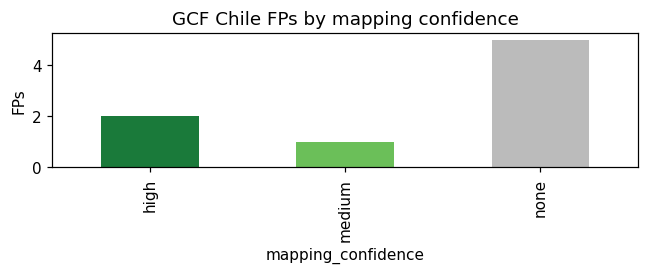

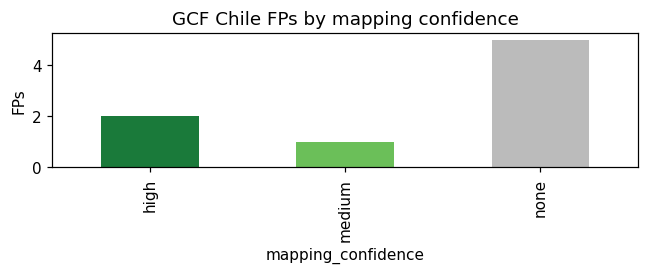

In [4]:
# Validate mapping, export, coverage chart
assert set(port['fp_id'])==set(xwalk['fp_id'])
assert not xwalk[xwalk.action_id!=''][['fp_id','action_id']].duplicated().any()
xwalk.to_csv('data/gcf_chile_to_actions.csv', index=False)
cov=xwalk['mapping_confidence'].value_counts().reindex(['high','medium','none']).fillna(0).astype(int)
mapped=int(cov.get('high',0)+cov.get('medium',0))
print(f'portfolio={len(port)} | mapped(high+medium)={mapped} | none={int(cov.get("none",0))}')
print('actions reached:', sorted(xwalk.loc[xwalk.action_id!="","action_id"].unique()))
fig,ax=plt.subplots(figsize=(6,2.6))
cov.plot.bar(ax=ax,color=['#1a7a3a','#6bbf59','#bbbbbb']); ax.set_title('GCF Chile FPs by mapping confidence'); ax.set_ylabel('FPs')
fig.tight_layout(); fig

## Findings

- **3 of 8 portfolio entries map** to a city action (FP189 e-mobility -> zero-emission buses [high]; FP120 REDD+ -> reduce deforestation [high]; FP017 solar -> solar generation [medium, utility-scale]).
- **5 are `none`**, for two structural reasons: (a) **finance vehicles** (FP151/152 Subnational Climate Fund, FP149 FI facility) are instruments not interventions; (b) the **water gap** (FP254 resilient water) and **readiness** (capacity) have no action archetype.
- The city-facing **FP189** is the headline: a real GCF programme financing electric buses/EV fleets in Chilean cities, reached via the IDB (AE) and the national government — model `access_pathway = intermediated`.
- **Not open calls.** These FPs are approved/under-implementation programmes (or completed), not application windows — see `application_status`. GCF's own apply route (concept note -> NDA no-objection -> AE -> Board) is continuous/rolling, not a dated concurso.
- **Adaptation out of scope.** FP254 (resilient water) is adaptation and flagged `in_scope = no` — not a taxonomy gap, just outside our mitigation-action scope. The in-scope mitigation set is what matters.
- Mapping is at FP grain, link-don't-attribute (multi-country FP financing is not a Chile figure). All medium/none rows **await human adjudication**.